In [1]:
import os
import sys
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Make "Data Analysis/spectral_analysis.py" importable from this notebook
MODULE_DIR = os.path.abspath(os.path.join("..", "Data Analysis"))
if MODULE_DIR not in sys.path:
    sys.path.append(MODULE_DIR)

import spectral_analysis as sa

print("spectral_analysis module loaded from:", sa.__file__)

spectral_analysis module loaded from: /mnt/New_Volume/Projects/Solar Detection/Data Analysis/spectral_analysis.py


In [2]:
# ---------------------------------------------------------------------
# EDIT THESE PATHS TO MATCH YOUR REPO LAYOUT
# ---------------------------------------------------------------------

# Build paths from the imported module location so they do not depend on
# the notebook kernel's current working directory.
PROJECT_DIR = os.path.dirname(MODULE_DIR)

IMAGES_DIR = os.path.join(PROJECT_DIR, "Data Analytics", "Google_MapStaticAPI", "images")

# COCO-format annotation export (CVAT / Roboflow / LabelMe->COCO etc.)
ANNOTATIONS_JSON = os.path.join(
    PROJECT_DIR, "Data Analytics", "Annotation", "merged_instances_default.json"
)

# If you instead have raster PNG masks (0/255) per image, set this True
# and point MASKS_DIR at that folder — the mask-folder loader will be
# used instead of the COCO loader.
USE_MASK_FOLDER = False
MASKS_DIR = os.path.join(PROJECT_DIR, "masks")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "Data Analysis","spectral_output")
os.makedirs(os.path.join(OUTPUT_DIR, "visualizations"), exist_ok=True)

cfg = sa.SpectralConfig()   # tweak thresholds/weights here if needed
cfg

SpectralConfig(gsd_m_per_px=0.15, capacity_kw_per_m2=0.2, hsv_lower=(95, 15, 15), hsv_upper=(135, 160, 130), lab_L_range=(25, 150), lab_a_range=(110, 145), lab_b_range=(100, 140), ycrcb_Y_range=(30, 190), ycrcb_Cr_range=(110, 150), ycrcb_Cb_range=(110, 150), kmeans_k=6, kmeans_attempts=5, canny_low=50, canny_high=150, min_blob_area_px=40, max_blob_area_px=20000, min_aspect_ratio=0.25, max_aspect_ratio=4.0, w_color=0.25, w_spectral=0.2, w_threshold=0.15, w_kmeans=0.2, w_edge=0.2, fusion_threshold=0.55, shadow_y_k=1.0, shadow_downweight=0.35)

In [3]:
if not USE_MASK_FOLDER:
    images_by_id, anns_by_image_id, categories = sa.load_coco_annotations(ANNOTATIONS_JSON)
    print(f"Loaded {len(images_by_id)} annotated images, categories: {categories}")
    sample_ids = list(images_by_id.keys())
else:
    image_files = sorted(
        f for f in os.listdir(IMAGES_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))
    )
    images_by_id = {i: {"file_name": f, "id": i} for i, f in enumerate(image_files)}
    anns_by_image_id = None
    sample_ids = list(images_by_id.keys())
    print(f"Found {len(sample_ids)} images with mask-folder annotations")

Loaded 2500 annotated images, categories: {1: 'hassolar'}


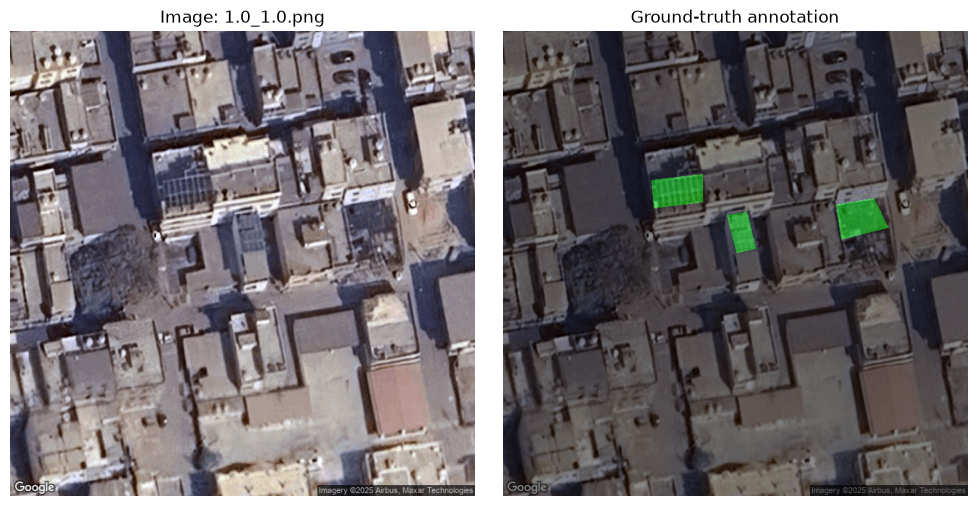

In [4]:
def load_gt_mask_for(image_id):
    info = images_by_id[image_id]
    img_path = os.path.join(IMAGES_DIR, info["file_name"])
    rgb = sa.load_image(img_path)
    h, w = rgb.shape[:2]

    if USE_MASK_FOLDER:
        mask_name = os.path.splitext(info["file_name"])[0] + ".png"
        gt_mask = sa.load_mask_folder_annotation(os.path.join(MASKS_DIR, mask_name))
    else:
        gt_mask = sa.ground_truth_mask_for_image(image_id, anns_by_image_id, h, w)

    return rgb, gt_mask


sample_id = sample_ids[0]
rgb, gt_mask = load_gt_mask_for(sample_id)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb); ax[0].set_title(f"Image: {images_by_id[sample_id]['file_name']}"); ax[0].axis("off")
ax[1].imshow(sa.overlay_mask(rgb, gt_mask, color=(0, 255, 0))); ax[1].set_title("Ground-truth annotation"); ax[1].axis("off")
plt.tight_layout(); plt.show()

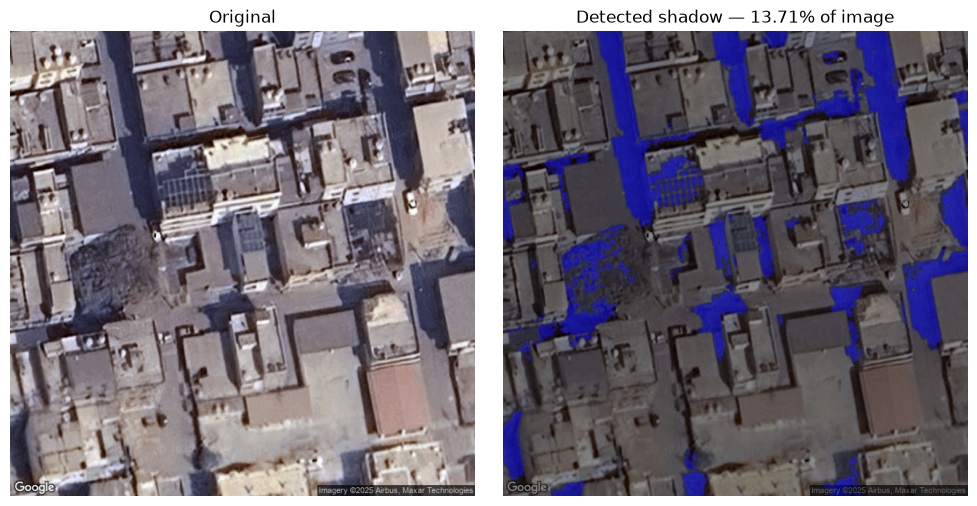

Shadow pixels: 56146 (13.71% coverage)


In [5]:
shadow_mask = sa.detect_shadow_mask(rgb, k=cfg.shadow_y_k)
coverage_pct = 100.0 * shadow_mask.sum() / shadow_mask.size

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(sa.overlay_mask(rgb, shadow_mask, color=(0, 0, 255)))
ax[1].set_title(f"Detected shadow — {coverage_pct:.2f}% of image"); ax[1].axis("off")
plt.tight_layout(); plt.show()

print(f"Shadow pixels: {int(shadow_mask.sum())} ({coverage_pct:.2f}% coverage)")

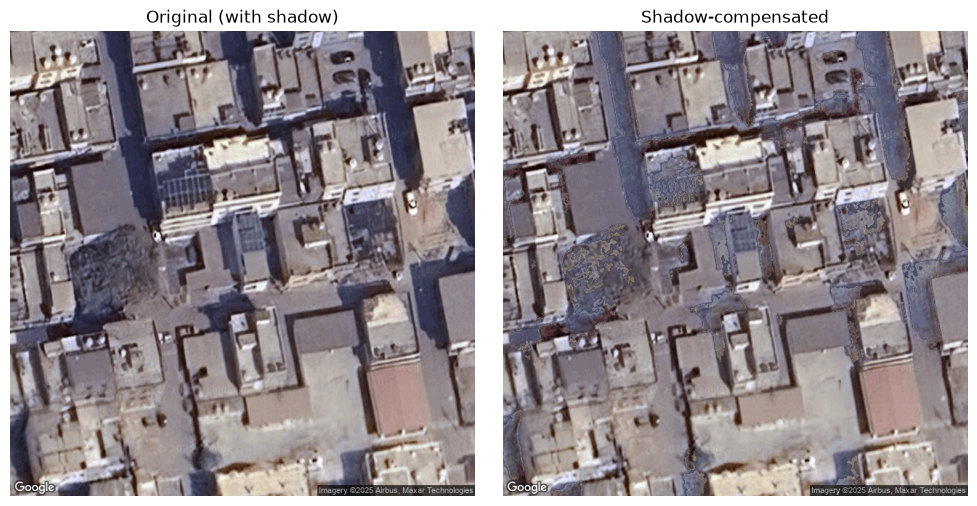

In [6]:
corrected_rgb = sa.remove_shadow_linear(rgb, shadow_mask)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb); ax[0].set_title("Original (with shadow)"); ax[0].axis("off")
ax[1].imshow(corrected_rgb); ax[1].set_title("Shadow-compensated"); ax[1].axis("off")
plt.tight_layout(); plt.show()

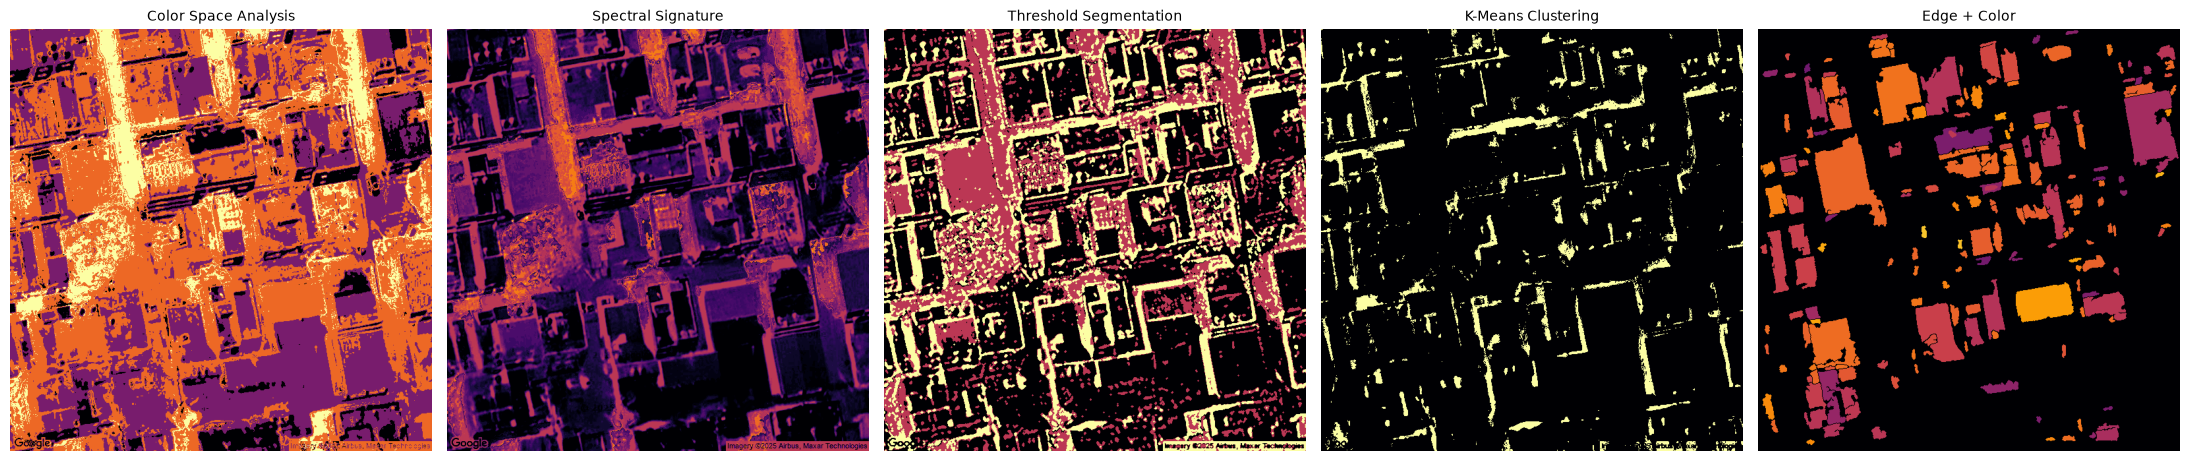

In [7]:
color_conf = sa.method_color_space(corrected_rgb, cfg)
spectral_conf = sa.method_spectral_signature(corrected_rgb)
threshold_conf = sa.method_threshold(corrected_rgb)
kmeans_conf = sa.method_kmeans(corrected_rgb, cfg)
edge_conf = sa.method_edge_color(corrected_rgb, cfg, color_confidence=color_conf)

method_maps = {
    "Color Space Analysis": color_conf,
    "Spectral Signature": spectral_conf,
    "Threshold Segmentation": threshold_conf,
    "K-Means Clustering": kmeans_conf,
    "Edge + Color": edge_conf,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, conf) in zip(axes, method_maps.items()):
    ax.imshow(conf, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()

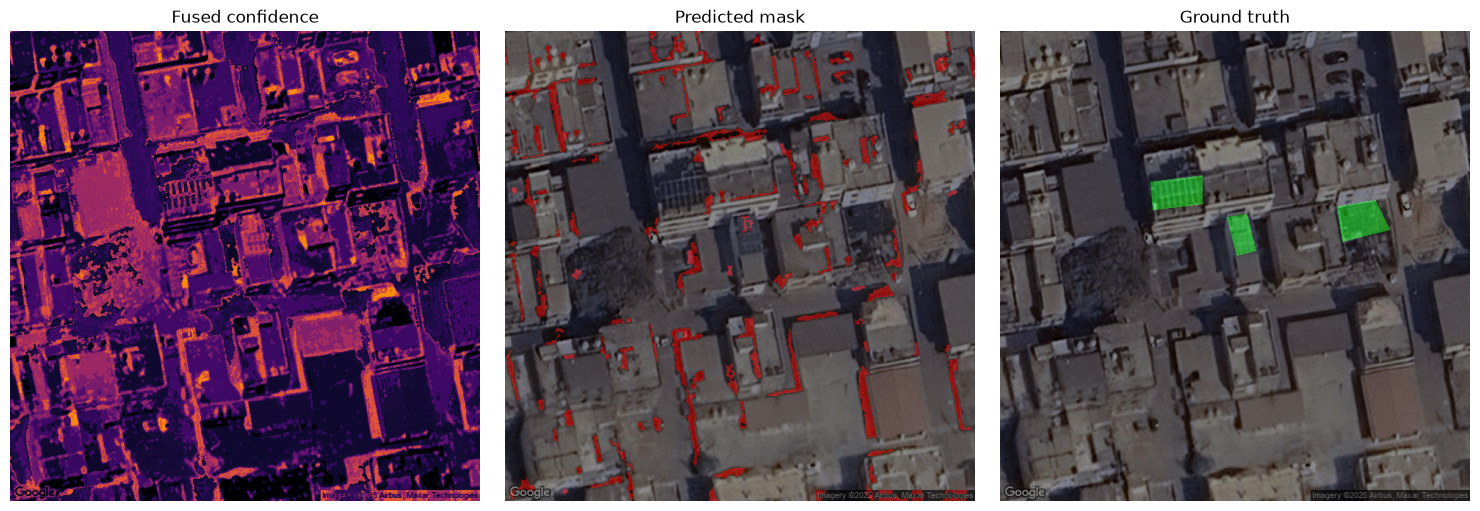

In [8]:
maps_for_fusion = {
    "color": color_conf,
    "spectral": spectral_conf,
    "threshold": threshold_conf,
    "kmeans": kmeans_conf,
    "edge": edge_conf,
}

fused_confidence = sa.fuse_confidence_maps(maps_for_fusion, cfg, shadow_mask=shadow_mask)
predicted_mask = sa.confidence_to_mask(fused_confidence, cfg)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(fused_confidence, cmap="inferno", vmin=0, vmax=1); ax[0].set_title("Fused confidence"); ax[0].axis("off")
ax[1].imshow(sa.overlay_mask(rgb, predicted_mask, color=(255, 0, 0))); ax[1].set_title("Predicted mask"); ax[1].axis("off")
ax[2].imshow(sa.overlay_mask(rgb, gt_mask, color=(0, 255, 0))); ax[2].set_title("Ground truth"); ax[2].axis("off")
plt.tight_layout(); plt.show()

In [9]:
iou = sa.compute_iou(predicted_mask, gt_mask)
prf = sa.compute_precision_recall_f1(predicted_mask, gt_mask)
area_m2, capacity_kw = sa.area_and_capacity(predicted_mask, cfg)

print(f"IoU:        {iou:.3f}")
print(f"Precision:  {prf['precision']:.3f}")
print(f"Recall:     {prf['recall']:.3f}")
print(f"F1:         {prf['f1']:.3f}")
print(f"Predicted area:     {area_m2:.2f} m^2")
print(f"Predicted capacity: {capacity_kw:.2f} kW")

IoU:        0.006
Precision:  0.007
Recall:     0.026
F1:         0.011
Predicted area:     584.55 m^2
Predicted capacity: 116.91 kW


In [10]:
results = []

for image_id in tqdm(sample_ids, desc="Scoring annotated dataset"):
    try:
        rgb_i, gt_mask_i = load_gt_mask_for(image_id)
        out = sa.run_pipeline(rgb_i, cfg, remove_shadows=True)

        iou_i = sa.compute_iou(out["predicted_mask"], gt_mask_i)
        prf_i = sa.compute_precision_recall_f1(out["predicted_mask"], gt_mask_i)
        area_i, capacity_i = sa.area_and_capacity(out["predicted_mask"], cfg)
        shadow_pct_i = 100.0 * out["shadow_mask"].sum() / out["shadow_mask"].size

        results.append({
            "sample_id": image_id,
            "file_name": images_by_id[image_id]["file_name"],
            "iou": iou_i,
            "precision": prf_i["precision"],
            "recall": prf_i["recall"],
            "f1": prf_i["f1"],
            "shadow_coverage_pct": shadow_pct_i,
            "predicted_area_m2": area_i,
            "predicted_capacity_kw": capacity_i,
        })
    except Exception as e:
        print(f"[WARN] Skipped {image_id} ({images_by_id[image_id]['file_name']}): {e}")

results_df = pd.DataFrame(results)
results_df.head()

Scoring annotated dataset:   0%|          | 0/2500 [00:00<?, ?it/s]

,sample_id,file_name,iou,precision,recall,f1,shadow_coverage_pct,predicted_area_m2,predicted_capacity_kw
0,1,1.0_1.0.png,0.056073,0.060026,0.459883,0.106191,13.707520,1209.6000,241.9200
1,2,10.0_1.0.png,0.035228,0.043383,0.157820,0.068058,11.514893,801.8100,160.3620
2,3,100.0_1.0.png,0.106655,0.172514,0.218369,0.192752,9.894531,854.9325,170.9865
3,4,101.0_1.0.png,0.003078,0.003959,0.013647,0.006137,7.248535,932.0625,186.4125
4,5,102.0_1.0.png,0.000030,0.000033,0.000367,0.000060,5.416016,688.7700,137.7540


             iou  precision    recall        f1  shadow_coverage_pct
mean    0.032850   0.057619  0.090296  0.060404             8.706197
median  0.015784   0.029974  0.043416  0.031078             9.098267
std     0.043953   0.074711  0.115035  0.075565             4.733787


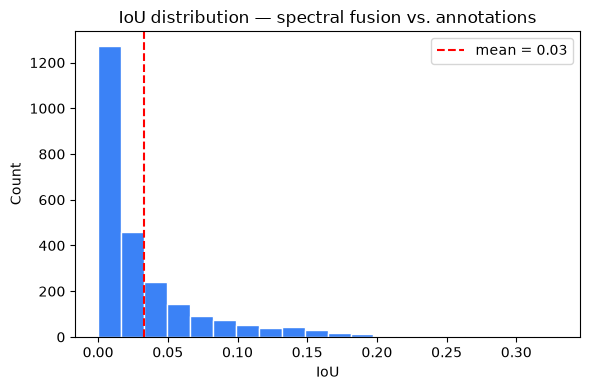

In [11]:
summary = results_df[["iou", "precision", "recall", "f1", "shadow_coverage_pct"]].agg(["mean", "median", "std"])
print(summary)

plt.figure(figsize=(6, 4))
plt.hist(results_df["iou"], bins=20, color="#3b82f6", edgecolor="white")
plt.axvline(results_df["iou"].mean(), color="red", linestyle="--", label=f"mean = {results_df['iou'].mean():.2f}")
plt.xlabel("IoU"); plt.ylabel("Count"); plt.title("IoU distribution — spectral fusion vs. annotations")
plt.legend(); plt.tight_layout(); plt.show()

In [12]:
N_EXAMPLES = 5
best = results_df.sort_values("iou", ascending=False).head(N_EXAMPLES)
worst = results_df.sort_values("iou", ascending=True).head(N_EXAMPLES)

def save_comparison(image_id, tag):
    rgb_i, gt_mask_i = load_gt_mask_for(image_id)
    out = sa.run_pipeline(rgb_i, cfg, remove_shadows=True)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(rgb_i); ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(sa.overlay_mask(rgb_i, out["predicted_mask"], color=(255, 0, 0)))
    ax[1].set_title("Predicted"); ax[1].axis("off")
    ax[2].imshow(sa.overlay_mask(rgb_i, gt_mask_i, color=(0, 255, 0)))
    ax[2].set_title("Ground truth"); ax[2].axis("off")
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, "visualizations", f"{tag}_{image_id}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

for _, row in best.iterrows():
    save_comparison(row["sample_id"], "best")
for _, row in worst.iterrows():
    save_comparison(row["sample_id"], "worst")

print(f"Saved {2 * N_EXAMPLES} comparison images to {os.path.join(OUTPUT_DIR, 'visualizations')}")

Saved 10 comparison images to /mnt/New_Volume/Projects/Solar Detection/Data Analysis/spectral_output/visualizations
